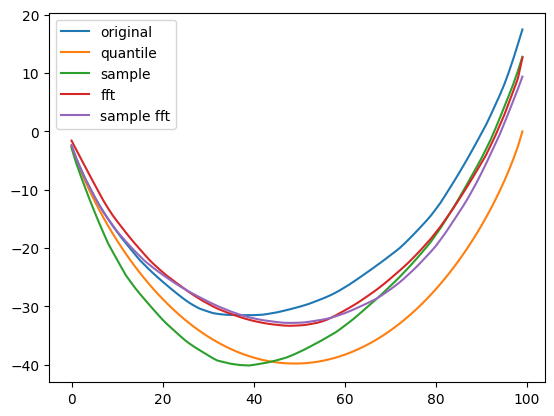

In [26]:
import multiprocessing as mp
import pandas as pd
import numpy as np
from scipy.stats import norm, rayleigh, pearsonr
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns


def normalise(vec):
    rv = norm(0, 1)
    return rv.ppf((np.argsort(np.argsort(vec)) + 0.5) / len(vec))

def samp_normalise(vec):
    rv = np.sort(norm.rvs(0, 1, size=len(vec)))
    return rv[np.argsort(np.argsort(vec))]

def fft_normalise(vec):
    sig = np.sqrt(len(vec)/2)
    rv = rayleigh(0, sig)
    amp = np.absolute(np.fft.rfft(vec))
    new_amp = rv.ppf((np.argsort(np.argsort(amp)) + 0.5) / len(amp))
    return np.fft.irfft(new_amp*np.exp(2 * np.pi * np.random.rand(len(new_amp)) * 1.0j), n=len(vec))

def sfft_normalise(vec):
    sig = np.sqrt(len(vec)/2)
    amp = np.absolute(np.fft.rfft(vec))
    rv = np.sort(rayleigh.rvs(0, sig, size=len(amp)))
    new_amp = rv[np.argsort(np.argsort(amp))]
    return np.fft.irfft(new_amp*np.exp(2 * np.pi * np.random.rand(len(new_amp)) * 1.0j), n=len(vec))


def single_iter(data):
    r, nsamples = data
    points = np.random.multivariate_normal([0,0], [[1,r],[r,1]], nsamples).T.copy()

    true_correlation = pearsonr(*points)[0]
    surr_correlation = pearsonr(normalise(points[0]),normalise(points[1]))[0]
    samp_correlation = pearsonr(samp_normalise(points[0]),samp_normalise(points[1]))[0]
    fft_correlation = pearsonr(fft_normalise(points[0]),fft_normalise(points[1]))[0]
    sfft_correlation = pearsonr(sfft_normalise(points[0]),sfft_normalise(points[1]))[0]
    return r, true_correlation, surr_correlation, samp_correlation, fft_correlation, sfft_correlation

x0 = np.random.normal(0,1,100)
x1 = normalise(x0)
x2 = samp_normalise(x0)
x3 = fft_normalise(x0)
x4 = sfft_normalise(x0)
plt.plot(np.cumsum(sorted(x0)), label="original")
plt.plot(np.cumsum(sorted(x1)), label="quantile")
plt.plot(np.cumsum(sorted(x2)), label="sample")
plt.plot(np.cumsum(sorted(x3)), label="fft")
plt.plot(np.cumsum(sorted(x4)), label="sample fft")
plt.legend()
plt.show()

In [27]:
correcting = []
iters = 10000
with mp.Pool(7) as pool:
    for r in tqdm([0, 0.3, 0.8], "Computing correction"):
        I = pool.map(single_iter, ((r, 400) for __ in range(iters)))
        correcting.append(pd.DataFrame(np.array(I), columns=["r0", "r", "sur", "samp", "fft", "sfft"]))
all_correcting = pd.concat(correcting)

Computing correction: 100%|██████████| 3/3 [00:24<00:00,  8.18s/it]


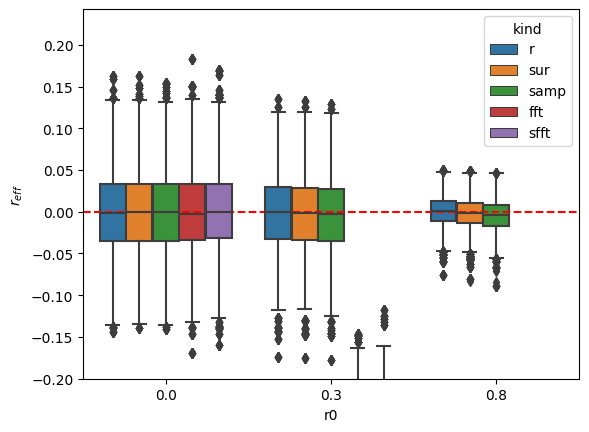

In [30]:
mytab = all_correcting.melt(["r0"], ["r", "sur", "samp", "fft", "sfft"], "kind", "$r_{eff}$")
mytab["$r_{eff}$"]=mytab["$r_{eff}$"]-mytab["r0"]
sns.boxplot(data=mytab, x="r0", y="$r_{eff}$", hue="kind")
xl=plt.xlim()
plt.plot(xl, [0,0], "--r")
plt.xlim(xl)
plt.ylim(bottom=-0.2)
plt.show()

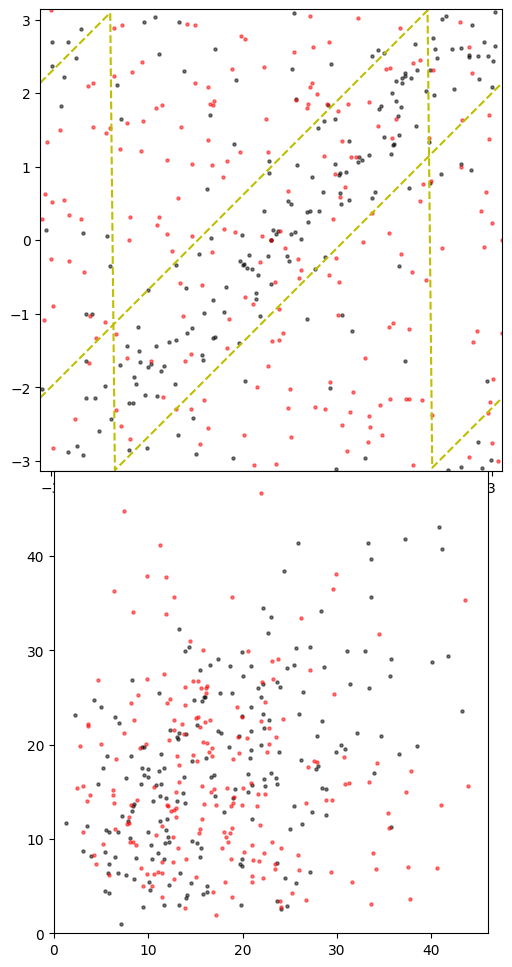

In [46]:
fig, ax = plt.subplots(2,1, figsize=(8,12))
plt.subplots_adjust(wspace=0.0, hspace=0.0) 


points = np.random.multivariate_normal([0,0], [[1,0.7],[0.7,1]], 400).T
a = np.fft.rfft(points[0])
b = np.fft.rfft(points[1])

plt.sca(ax[0])
plt.scatter(np.angle(a), np.angle(b), color="k", s=5, alpha=0.5, label=1)
plt.sca(ax[1])
plt.scatter(np.absolute(a), np.absolute(b), color="k", s=5, alpha=0.5, label=1)


points[0]=np.random.normal(0,1,400)
points[1]=np.random.normal(0,1,400)
a = np.fft.rfft(points[0])
b = np.fft.rfft(points[1])

plt.sca(ax[0])
plt.scatter(np.angle(a), np.angle(b), color="r", s=5, alpha=0.5, label=1)

plt.xlim([-np.pi,np.pi])
plt.ylim([-np.pi,np.pi])
x=np.linspace(-np.pi, np.pi, 100)
y1=np.mod(x+1-np.pi, 2*np.pi)-np.pi
plt.plot(x, y1, "--y")
y2=np.mod(x-1-np.pi, 2*np.pi)-np.pi
plt.plot(x, y2, "--y")


plt.sca(ax[1])
plt.scatter(np.absolute(a), np.absolute(b), color="r", s=5, alpha=0.5, label=1)

plt.xlim(left=0)
plt.ylim(bottom=0)


ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
plt.show()

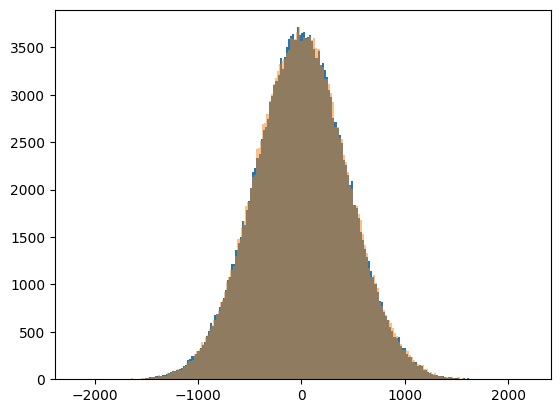

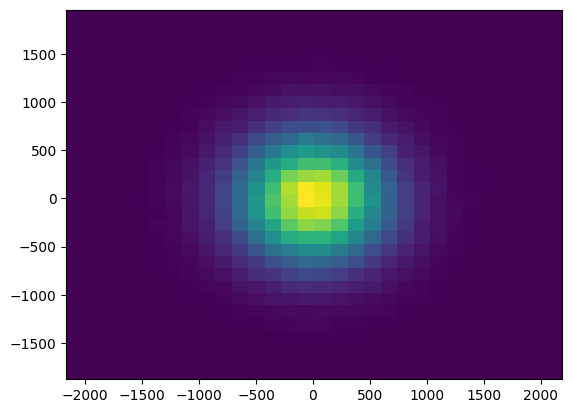

In [56]:
L=400000
sig = np.sqrt(L/2)
tot = L//2+1
r = rayleigh.rvs(0, sig, size=tot)
f = 2*np.pi*np.random.random(tot)
x = r*np.cos(f)
y = r*np.sin(f)
plt.hist(x, bins="auto")
plt.hist(y, bins="auto", alpha=0.5)
plt.show()
plt.hist2d(x, y, bins=30)
plt.show()

In [60]:
amp = np.imag(np.fft.rfft(np.random.multivariate_normal([0,0], np.array([[1,0.7],[0.7, 1]]), 400).T, axis=1))
pearsonr(*amp)

PearsonRResult(statistic=0.6900824638570004, pvalue=9.258685686207499e-30)